<h1 style="color:red;">Numerical Simulation Laboratory - Exercise 9.1</h1>

The aim of this exercise is to implement a **Genetic Algorithm (GA)** to solve the Traveling Salesman Problem (TSP) for a system of $34$ cities. The goal of the problem is to find the shortest possible closed path that visits each city exactly once and returns to the starting city.

The Genetic Algorithm is applied to two different spatial configurations of the cities. In the first case, the $34$ cities are randomly distributed along a circumference, while in the second case they are randomly distributed inside a square.

For each configuration, the evolution of the population is followed over successive generations, and the length of the best path found is used to monitor the convergence of the algorithm towards an optimal solution.

### Genetic Algorithms

A Genetic Algorithm (GA) is an optimization method inspired by the evolutionary processes observed in nature. Biological evolution explores a vast space of possible configurations and progressively favours those that are better adapted to the surrounding environment. This process is driven by random mutations and by the natural selection of individuals with more favourable characteristics, whose genetic information is more likely to be transmitted to subsequent generations.

A Genetic Algorithm reproduces this mechanism computationally. A set of possible solutions to a problem is represented as a **population of chromosomes**, where each chromosome encodes a particular solution. Starting from an initial population, new generations are produced by applying genetic operators such as **crossover** and **mutation**. Crossover combines parts of different chromosomes, while mutation introduces random modifications into individual chromosomes. A **selection operator** is then used to determine which individuals are more likely to contribute to the next generation.

The selection is based on the **fitness** of each individual, which provides a measure of the quality of the corresponding solution for the optimization problem. Individuals with a better fitness are therefore more likely to be selected and to transmit their characteristics to the following generations. Repeating this procedure allows the population to progressively evolve towards better solutions.

### The Traveling Salesman Problem

The Traveling Salesman Problem (TSP) consists of a salesman and a set of $N$ cities with positions $\vec{c}_i$. The salesman has to visit each city exactly once, starting from a given city and eventually returning to the same city. The objective is to find the path that minimizes the total length of the trip.

Consider an ordered sequence of cities,

$$
\vec{c}_1,\vec{c}_2,\dots,\vec{c}_N,
$$

and let $$\vec{x}_1,\vec{x}_2,\dots,\vec{x}_N$$ denote the order in which the cities are visited. The path can be evaluated through a cost function. Two possible choices are

$$
L^{(2)}(\vec{x}_1,\vec{x}_2,\dots,\vec{x}_N)
=\sum_{i=1}^{N}
|\vec{x}_i-\vec{x}_{i+1}|^2,
$$

or

$$
L^{(1)}(\vec{x}_1,\vec{x}_2,\dots,\vec{x}_N)
=\sum_{i=1}^{N}
|\vec{x}_i-\vec{x}_{i+1}|,
$$

with

$$
\vec{x}_{N+1}=\vec{x}_1.
$$

The second expression corresponds to the total length of the path, while the first one considers the sum of the squared distances between consecutive cities. In this exercise, the cost function adopted is $L^{(1)}$.

A possible path corresponds to a particular permutation $P$ of the ordered sequence of cities,

$$
\vec{x}_1,\vec{x}_2,\dots,\vec{x}_N
=\vec{c}_{P_1},\vec{c}_{P_2},\dots,\vec{c}_{P_N}.
$$

The TSP can therefore be formulated as a combinatorial optimization problem in which the objective is to find the permutation that minimizes the chosen cost function. Any permutation of the cities can be generated through a suitable combination of elementary permutations between pairs of cities.

A possible path can be conveniently represented by a one-dimensional vector whose elements are integers identifying the cities in the order in which they are visited.

In the Genetic Algorithm, each such vector represents a **chromosome**, while the ordering of its elements defines the corresponding individual solution to the TSP.

### Implementation of the Genetic Algorithm

The implementation of the Genetic Algorithm is divided into two main files. The `Cities.cpp` file contains the functions used to generate the spatial configuration of the cities, while `TSP.cpp` contains the functions implementing the Genetic Algorithm and the evaluation of the possible paths.

The function `generate_cities` in `Cities.cpp` generates a set of $N$ cities by repeatedly applying a user-defined generator function. In this exercise two configuration of $34$  cities are generated: cities distributed on a circumference and cities randomly distributed inside a square.

The main functions implementing the Genetic Algorithm are contained in `TSP.cpp`. A possible solution is represented by an `Individual`, which contains a path, represented as a permutation of the city indices, and the corresponding path cost.

The function `random_path` generates a random valid chromosome. The first city is always fixed to city $0$, while the remaining cities are randomly permuted.

The validity of a chromosome is checked by the function `check_path`. It verifies that the path contains exactly all the cities, that the first city is city $0$, that all city indices are valid, and that no city appears more than once.

The function `cost` calculates the total length of a path using the cost function $L^{(1)}$,

$$
L^{(1)}=
\sum_{i=1}^{N}
\left|\vec{x}_i-\vec{x}_{i+1}\right|,
$$

with $\vec{x}_{N+1}=\vec{x}_1$. Therefore, the distance between the last and the first city is also included, ensuring that the path is closed.

The function `generate_population` creates the initial population of $M$ individuals. For each individual, a random valid path is generated using `random_path`, and its cost is calculated using `cost`.

The population is then sorted using `sort_population`, which orders the individuals according to their path cost in increasing order. Consequently, the first individual of the population corresponds to the best solution currently available.

The function `select` implements the selection mechanism. A random number $r\in[0,1)$ is transformed according to

$$
j=\left\lfloor M r^p\right\rfloor,
$$

where $p$ is the selection parameter. For $p>1$, this distribution favours smaller values of $j$ and therefore increases the probability of selecting individuals near the beginning of the sorted population, which have better fitness.

The `crossover` function combines two parent chromosomes to generate two new individuals. Since a chromosome in the TSP represents a permutation of the cities, the crossover must preserve the condition that every city appears exactly once. Two crossover points are randomly selected. The segment between these points is copied from `parent1` to `child1` and from `parent2` to `child2`. The remaining positions of `child1` are filled with the cities from `parent2`, while those of `child2` are filled with the cities from `parent1`, skipping in both cases the cities that have already been inserted. This procedure produces two valid permutations while combining genetic information from both parents.

The function `mutate` introduces random modifications to a chromosome in order to maintain genetic diversity and explore different regions of the solution space. Four different mutation operators are implemented:

- **Pair permutation:** two cities, excluding the fixed starting city, are randomly selected and exchanged.
- **Shift:** a consecutive block of cities is selected and shifted to another position while preserving the order of the cities inside the block.
- **Block permutation:** two blocks of equal length are selected and exchanged, while preserving the order of the cities within each block.
- **Inversion:** a consecutive segment of the path is selected and its order is reversed.

Each mutation is applied independently according to its corresponding probability. Since all these operations modify only the ordering of the cities, they preserve the permutation structure of the chromosome. After the mutations, the path cost is recalculated and associated with the updated individual.

The function `generate_new_population` constructs the next generation by generating two individuals at a time. First, **elitism** is applied by directly preserving the first $200$ best individuals of the current population. This corresponds to 10% of the total population and was chosen to allow the best individuals to continue reproducing in the following generations, while avoiding excessive elitism that could lead to premature convergence and algorithm stagnation. The remaining individuals are generated by selecting two parents according to the selection probability. With probability $p_{\mathrm{crossover}}$, the crossover operator is applied, producing two children from the selected parents. If crossover is not performed, the two children are simply copies of the two selected parents. The two resulting individuals are then subjected to the mutation operators before being added to the new population.

Finally, the function `best_half_average` calculates the average cost of the best half of the population. This quantity provides an additional measure of the evolution of the population and allows the convergence of the algorithm to be monitored together with the cost of the best individual.

### Initial parameters

The main parameters used for the Genetic Algorithm are reported below. The number of cities is fixed to $N=34$, while the initial population consists of $M=2000$ individuals. $n_{eite}=200$ individuals are preserved through elitism and the algorithm is evolved for $n_{generations}=500$ generations. The selection parameter is set to $p=2$, with a crossover probability of $p_{\mathrm{crossover}}=0.6$. Each of the four mutation operators $p_{\mathrm{pair}},  p_{\mathrm{shift}}, 
p_{\mathrm{block}},  p_{\mathrm{inversion}}$ is applied independently with probability $0.05$:


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def plot_TSP(cost_file, path_file):

    cost_data = np.loadtxt(cost_file)

    generation = cost_data[:, 0]
    best_prog = cost_data[:, 2]
    best_half = cost_data[:, 3]

    cities = np.loadtxt(path_file)

    x = cities[:, 0]
    y = cities[:, 1]

    fig, ax = plt.subplots(1, 2, figsize=(14, 6))

    ax[0].plot(
        generation,
        best_half,
        label="Average best half"
    )

    ax[0].plot(
        generation,
        best_prog,
        label="Progressive best"
    )
    
    ax[0].set_xlabel("Generation")
    ax[0].set_ylabel("Cost")
    ax[0].set_title("TSP cost convergence")

    ax[0].grid(True, alpha=0.3)
    ax[0].legend()

    # Close the path by returning to the first city
    x_path = np.append(x, x[0])
    y_path = np.append(y, y[0])

    ax[1].plot(
        x_path,
        y_path,
        "-o",
        markersize=4
    )

    # Number the cities
    for i in range(len(x)):
        ax[1].annotate(
            str(i),
            (x[i], y[i]),
            xytext=(5, 5),
            textcoords="offset points"
        )

    ax[1].set_xlabel("x")
    ax[1].set_ylabel("y")
    ax[1].set_title("Best path")

    ax[1].grid(True, alpha=0.3)

    # Since the cities are on a circle, this prevents
    # the plot from being distorted.
    ax[1].set_aspect("equal")

    plt.tight_layout()
    plt.show()

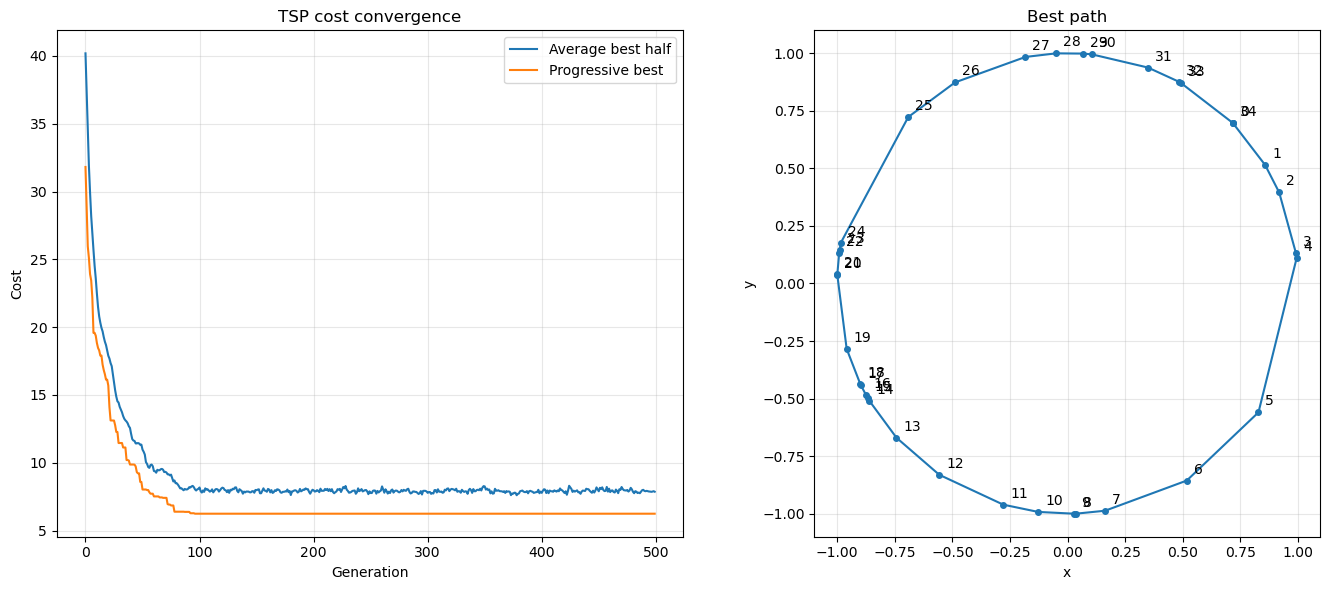

In [3]:
plot_TSP("Best_cost_circle.dat", "Best_path_circle.dat")

**Figure 1.** Evolution of the best path cost and of the average cost of the best half of the population as a function of the number of generations (left), together with the best path found by the algorithm (right). The best cost decreases monotonically throughout the evolution. The average cost of the best half, instead, is not necessarily monotonic and remains consistently higher than the best cost. The minimum path cost obtained for the circular configuration is

$$
L^{(1)}_{\mathrm{min}}=6.24306.
$$

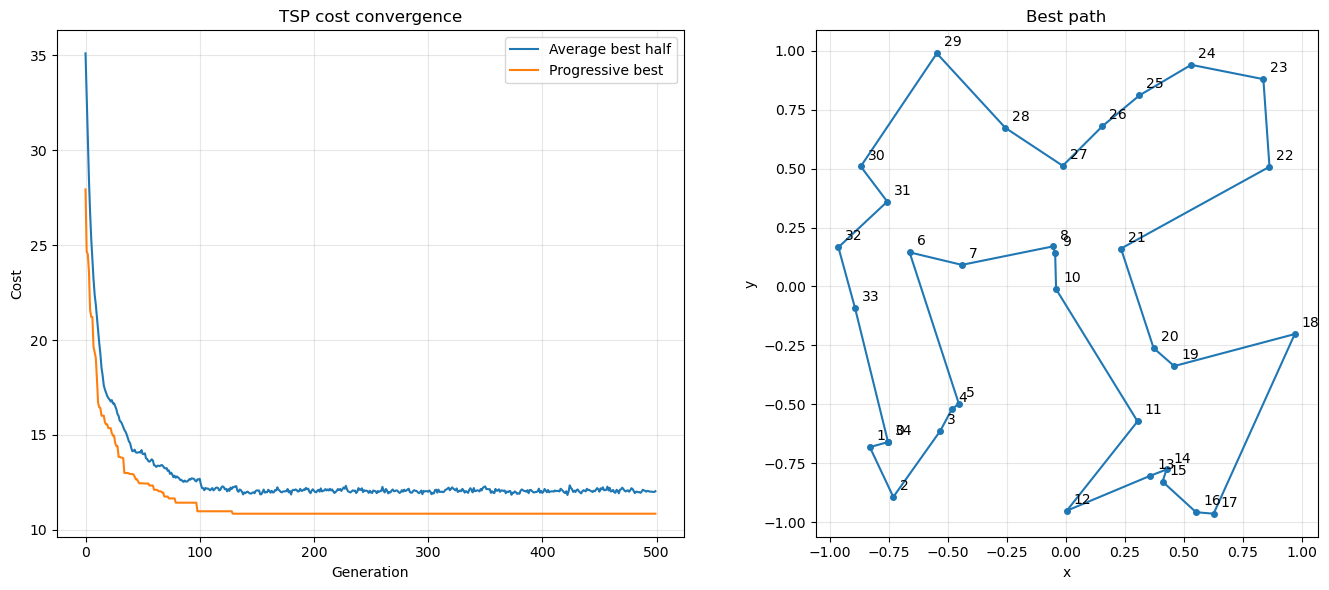

In [4]:
plot_TSP("Best_cost_square.dat", "Best_path_square.dat")

**Figure 2.** Evolution of the best path cost and of the average cost of the best half of the population as a function of the number of generations (left), together with the best path found by the algorithm (right). As in the circular configuration, the best cost decreases monotonically throughout the evolution, while the average cost of the best half is not necessarily monotonic and remains higher than the best cost. The minimum path cost obtained for the square configuration is

$$
L^{(1)}_{\mathrm{min}}=10.8523.
$$